Generating fresh data for the simulation...
Updated bangladesh_energy_data.csv successfully for year 2060.


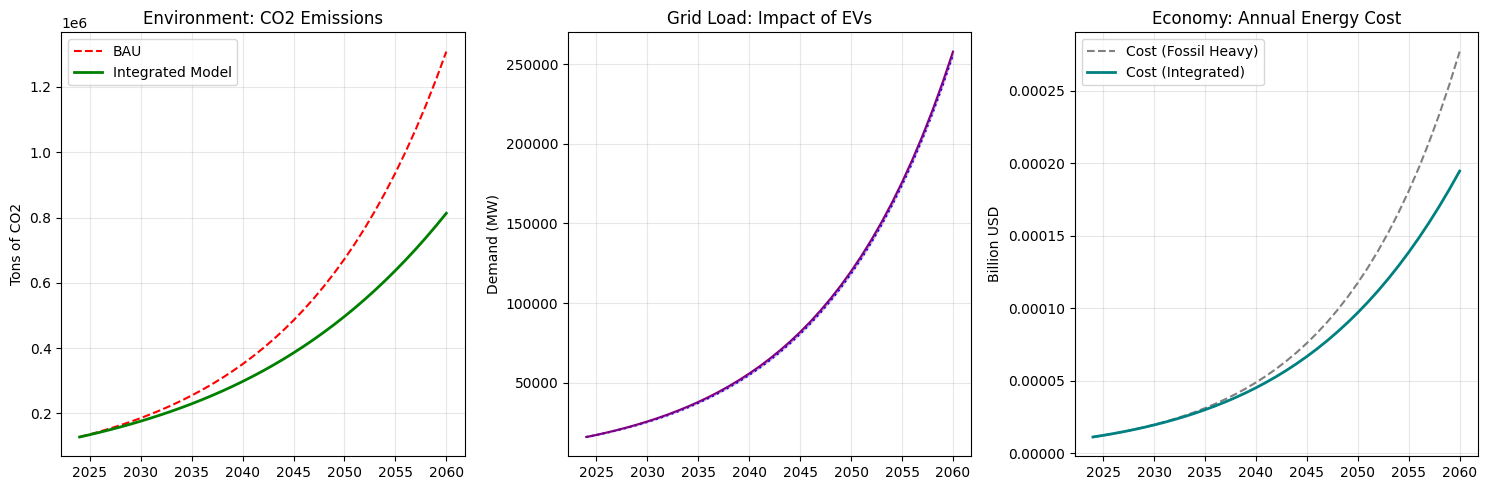


SIMULATION SUCCESSFUL
File saved at: /content/Thesis_Results_Final.csv

Data Preview (First 5 Rows):
   Year  Demand_MW_BAU  Emission_Tons_BAU  Cost_Billion_USD_BAU       Scenario_BAU  Demand_MW_Integrated  Emission_Tons_Integrated  Cost_Billion_USD_Integrated Scenario_Integrated
0  2024   16000.000000      127977.600000              0.000011  Business As Usual          16000.000000             127977.600000                     0.000011    Integrated Model
1  2025   17288.108108      136160.467153              0.000012  Business As Usual          17344.864865             135086.346145                     0.000012    Integrated Model
2  2026   18678.616216      144886.956213              0.000013  Business As Usual          18792.129730             142557.848440                     0.000013    Integrated Model
3  2027   20179.716324      154194.805688              0.000015  Business As Usual          20349.986595             150411.629512                     0.000015    Integrated Mode

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

LCOE_FOSSIL_2024 = 0.08
LCOE_RE_2024 = 0.06

csv_filename = "bangladesh_energy_data.csv"

print(f"Generating fresh data for the simulation...")
calculate_years = np.arange(2024, 2061) 

current_data = {
    'Year': calculate_years,
    'Base_Demand_MW': [16000 * (1.08)**i for i in range(len(calculate_years))],
    'Gas_Price_Index': [1.0 + (0.02*i) for i in range(len(calculate_years))],
    'Solar_Cost_Index': [max(0.3, 1.0 - (0.015*i)) for i in range(len(calculate_years))]
}
pd.DataFrame(current_data).to_csv(csv_filename, index=False)
print(f"Updated {csv_filename} successfully for year {calculate_years[-1]}.")

def run_integrated_simulation(scenario_name, ev_target, re_target, use_csv=True):
    if use_csv and os.path.exists(csv_filename):
        df_input = pd.read_csv(csv_filename)
        years = df_input['Year'].values
        base_demands = df_input['Base_Demand_MW'].values
        gas_price_factors = df_input['Gas_Price_Index'].values
        solar_cost_factors = df_input['Solar_Cost_Index'].values
    else:
        years = np.arange(2024, 2061)
        base_demands = [16000 * (1.08)**i for i in range(len(years))]
        gas_price_factors = [1.0] * len(years)
        solar_cost_factors = [1.0] * len(years)

    results = []

    for i, year in enumerate(years):
        demand = base_demands[i]
        progress_ratio = i / len(years)
        
        ev_share = ev_target * progress_ratio
        ev_load_mw = ev_share * 6000
        total_demand = demand + ev_load_mw
        
        current_re_share = 0.03 + (re_target * progress_ratio)
        fossil_share = 1 - current_re_share
        
        total_energy_gwh = total_demand * 8.76 / 1000
        emissions_power = (total_energy_gwh * fossil_share * 0.5 * 1000)
        
        base_transport_emission = 60000 * (1.05)**i
        saved_emission = base_transport_emission * ev_share
        net_transport_emission = base_transport_emission - saved_emission
        total_emission = emissions_power + net_transport_emission

        # Costs
        cost_fossil_unit = LCOE_FOSSIL_2024 * gas_price_factors[i]
        cost_re_unit = LCOE_RE_2024 * solar_cost_factors[i]
        
        total_cost_fossil = (total_energy_gwh * fossil_share * 1000 * cost_fossil_unit) / 1e9
        total_cost_re = (total_energy_gwh * current_re_share * 1000 * cost_re_unit) / 1e9
        total_system_cost = total_cost_fossil + total_cost_re

        results.append({
            "Year": year,
            "Demand_MW": total_demand,
            "Emission_Tons": total_emission,
            "Cost_Billion_USD": total_system_cost,
            "Scenario": scenario_name
        })

    return pd.DataFrame(results)

df_bau = run_integrated_simulation("Business As Usual", ev_target=0.05, re_target=0.10)
df_integrated = run_integrated_simulation("Integrated Model", ev_target=0.40, re_target=0.45)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(df_bau['Year'], df_bau['Emission_Tons'], color='red', linestyle='--', label='BAU')
plt.plot(df_integrated['Year'], df_integrated['Emission_Tons'], color='green', linewidth=2, label='Integrated Model')
plt.title('Environment: CO2 Emissions')
plt.ylabel('Tons of CO2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(df_bau['Year'], df_bau['Demand_MW'], color='blue', linestyle=':', label='Base Demand')
plt.plot(df_integrated['Year'], df_integrated['Demand_MW'], color='purple', label='Total Demand (with EV)')
plt.fill_between(df_integrated['Year'], df_bau['Demand_MW'], df_integrated['Demand_MW'], color='purple', alpha=0.2)
plt.title('Grid Load: Impact of EVs')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(df_bau['Year'], df_bau['Cost_Billion_USD'], color='gray', linestyle='--', label='Cost (Fossil Heavy)')
plt.plot(df_integrated['Year'], df_integrated['Cost_Billion_USD'], color='teal', linewidth=2, label='Cost (Integrated)')
plt.title('Economy: Annual Energy Cost')
plt.ylabel('Billion USD')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Thesis_Final_Analysis.png')
plt.show()

final_comparison = pd.merge(df_bau, df_integrated, on="Year", suffixes=('_BAU', '_Integrated'))

filename = "Thesis_Results_Final.csv"
final_comparison.to_csv(filename, index=False)

full_path = os.path.abspath(filename)

print("\n" + "="*50)
print("SIMULATION SUCCESSFUL")
print("="*50)
print(f"File saved at: {full_path}")
print("="*50)

pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)       

print("\nData Preview (First 5 Rows):")
print(final_comparison.head())
print("\nData Preview (Last 5 Rows):")
print(final_comparison.tail())